# Clustering

1. Medidas de similitud
- Para atributos continuos: Métricas de distancia
- Para atributos no continuos
2. Método de agrupamiento
- k-means
- Clustering jerárquico
3. Evaluación de resultados
- Validación de resultados

### ¿Dónde podemos aplicar el algoritmo de agrupación por clústers en la vida real?
- Segmentación de mercado
- Medicina, por ejemplo, detección de tumores
- Detección de fraudes
- Simplemente para identificar algunos grupos de clientes en la empresa o negocios

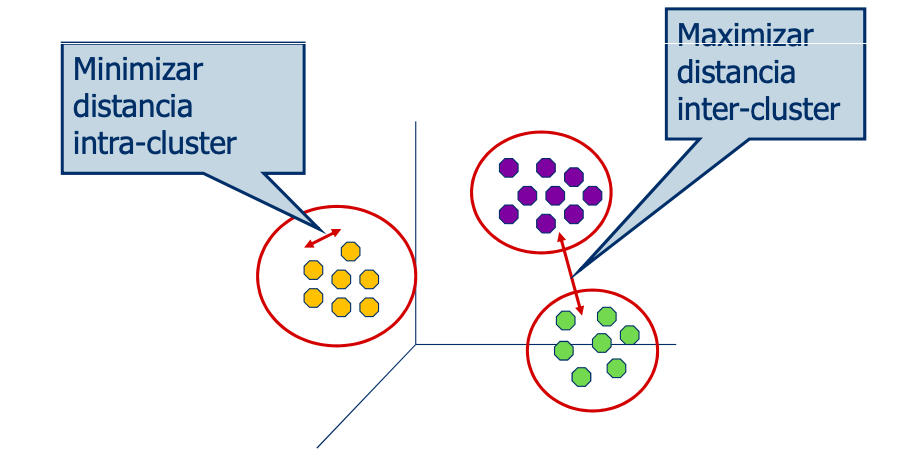

## Aprendizaje no supervisado
No existen clases predefinidas

## Los resultados obtenidos dependerán de:
- El algoritmo de agrupamiento seleccionado
- El conjunto de datos disponible
- La medida de similitud utilizada para comparar objetos (usualmente, definida como medida de distancia). 

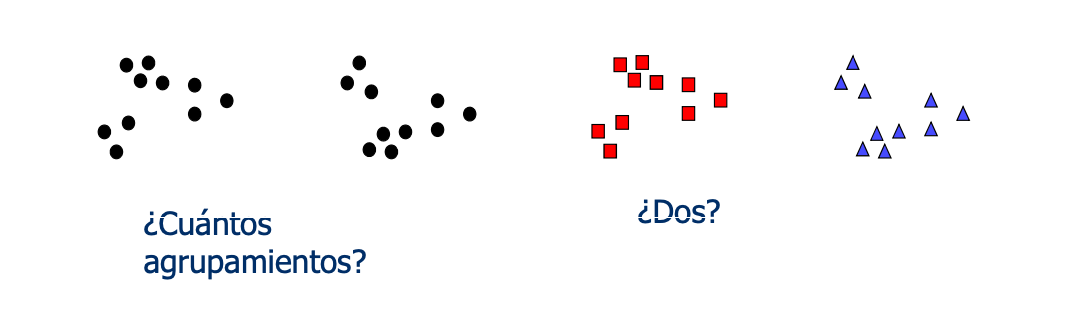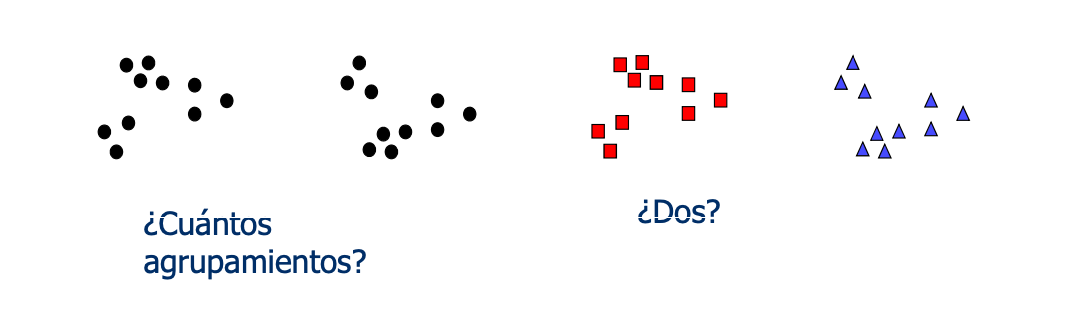
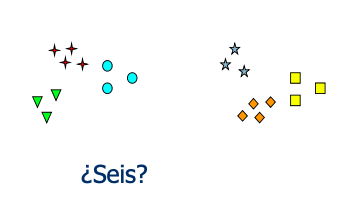

## ¿Cuál es la forma natural de agrupar los personajes?

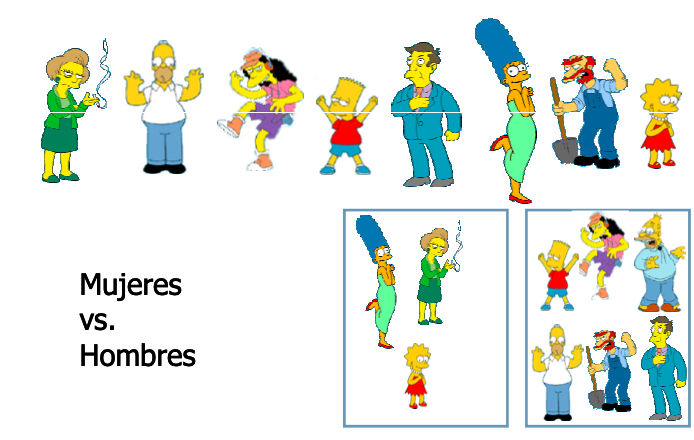
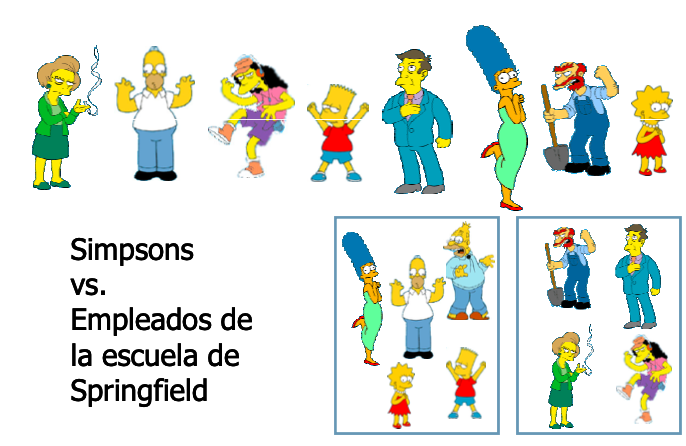

## ¿Cuál es la forma natural de agrupar los personajes?
<img src="imagen6.png">

# ¡El clustering es subjetivo!

# Medidas de similitud

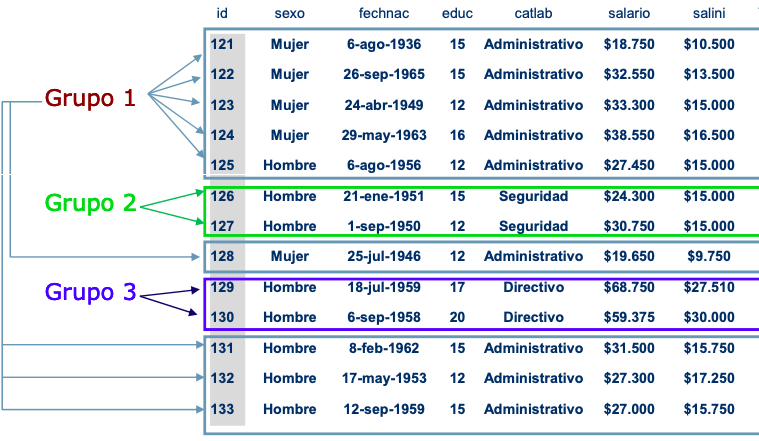

## A la hora de calcular la similitud entre dos objetos:
- No tienen por qué utilizarse todos los atributos disponibles en nuestro conjunto de datos. 
- Hay que tener cuidado con las magnitudes de cada variable.

## Atributos continuos
Para evitar que unas variables dominen sobre otras, los valores de los atributos se "normalizan" a priori:

- Desviación absoluta media:
$$s_f = \frac{1}{n}(|x_{1f}-m_f|+|x_{2f}-m_f|+...+|x_{nf}-m_f|)$$
donde
$$m_f = \frac{1}{n}(x_{1f}+x_{2f}+...+x_{nf})$$

- z-score (medida estandarizada):
$$z_{if}=\frac{x_{if}-m_f}{s_f}$$

Se suelen usar medidas de distancia porque verifican las siguientes propiedades:

- Propiedad reflexiva: $d(i,j)=0$ si y sólo si $i=j$
- Propiedad simétrica:  $d(i,j)=d(j,i)$
- Desigualdad triangular: $d(i,j)\leq d(i,k)+d(k,j)$

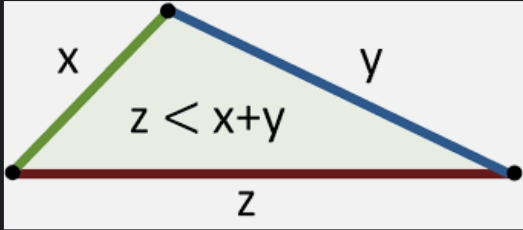

### Distancias
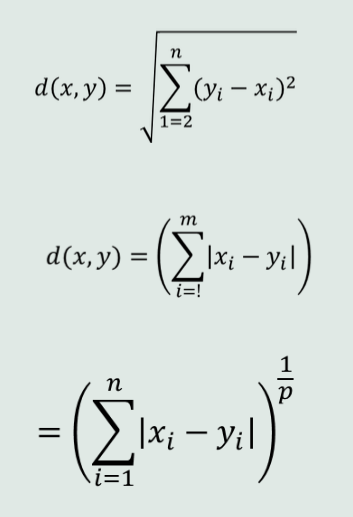

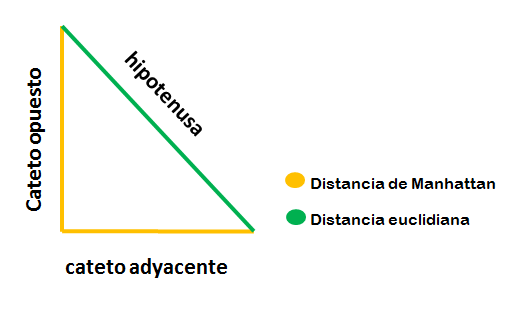

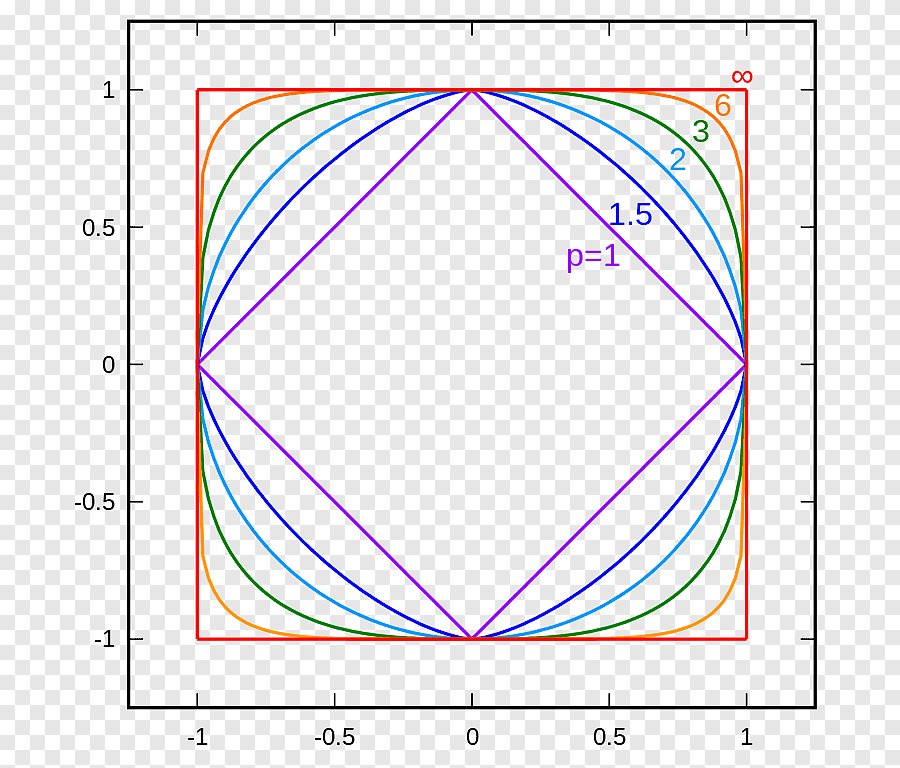 


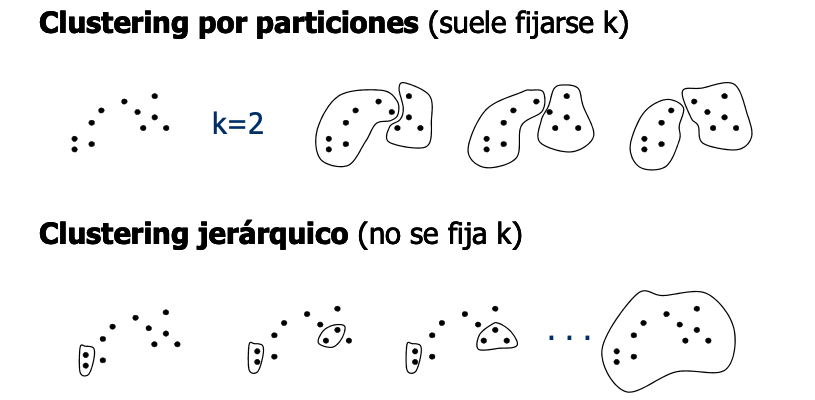

# k-Means
- Algoritmo de agrupamiento por particiones
- Número de clusters conocido (k)
- Cada cluster tiene asociado un centroide 
  (centro geométrico del cluster)
- Los puntos se asignan al cluster cuyo centroide esté más cerca (utilizando cualquier métrica de distancia). 
-  Iterativamente, se van actualizando los centroides en función de las asignaciones de puntos a clusters, hasta que los centroides dejen de cambiar. 

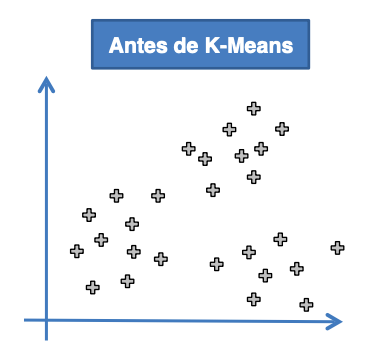

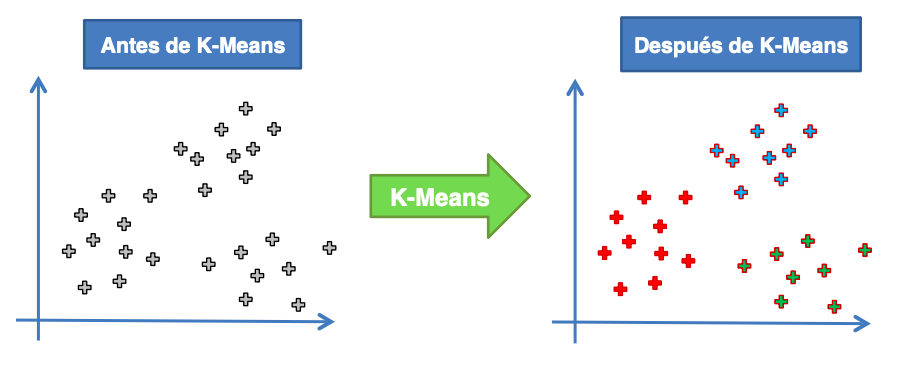

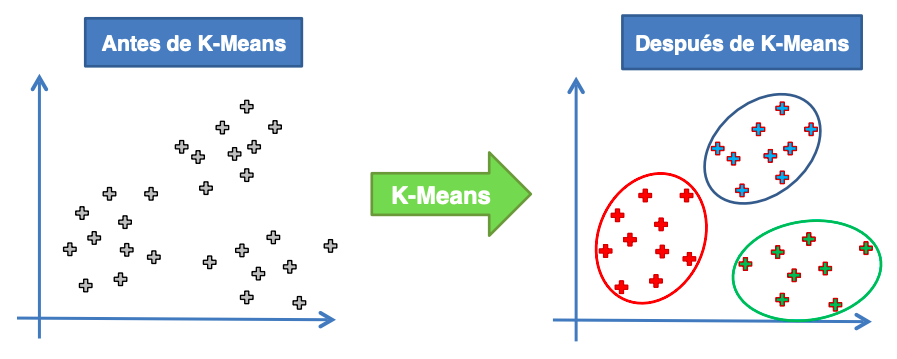

# Algoritmo
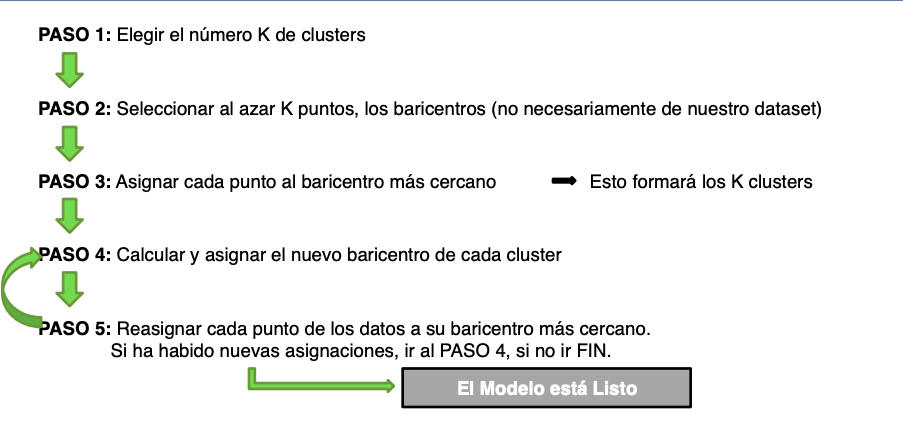

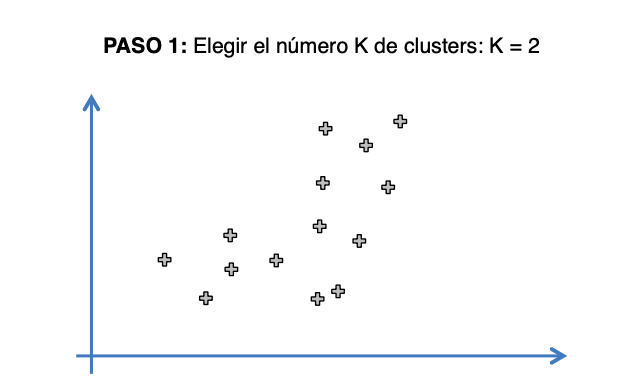

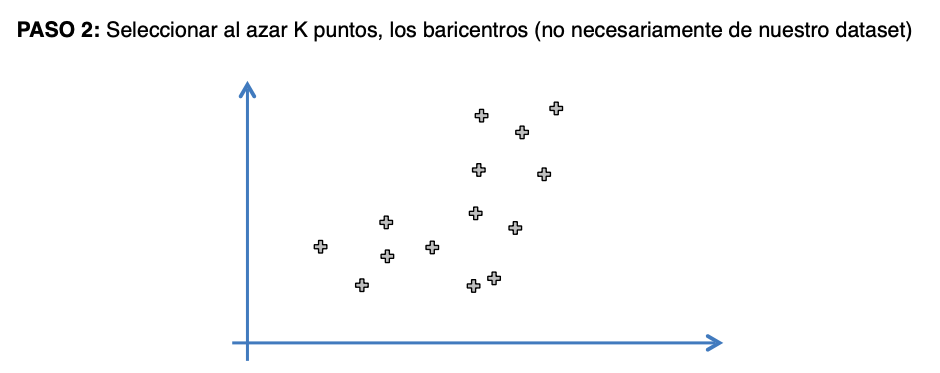

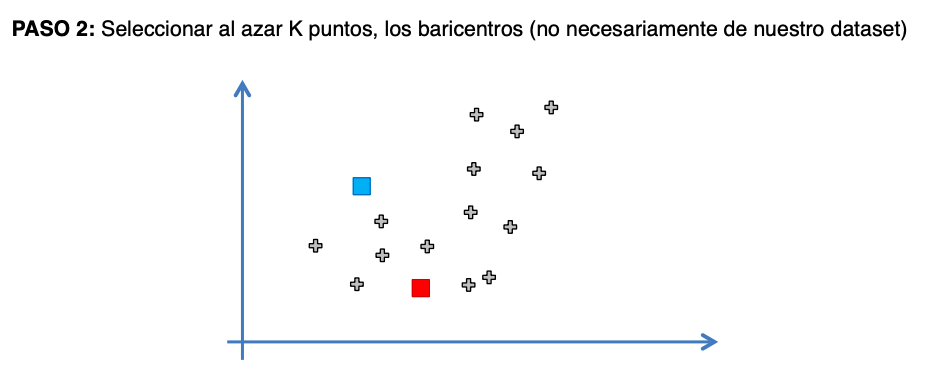

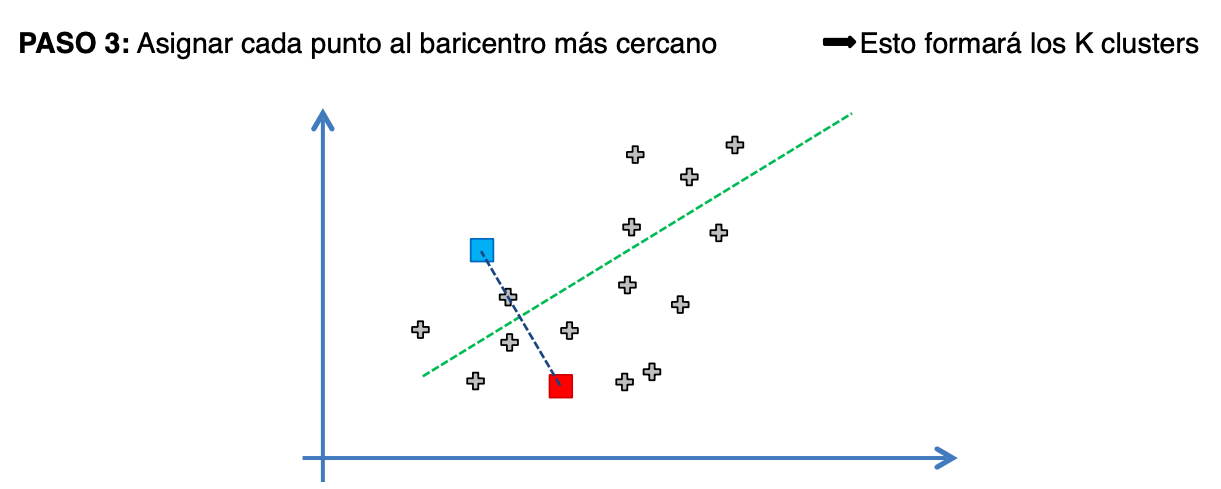

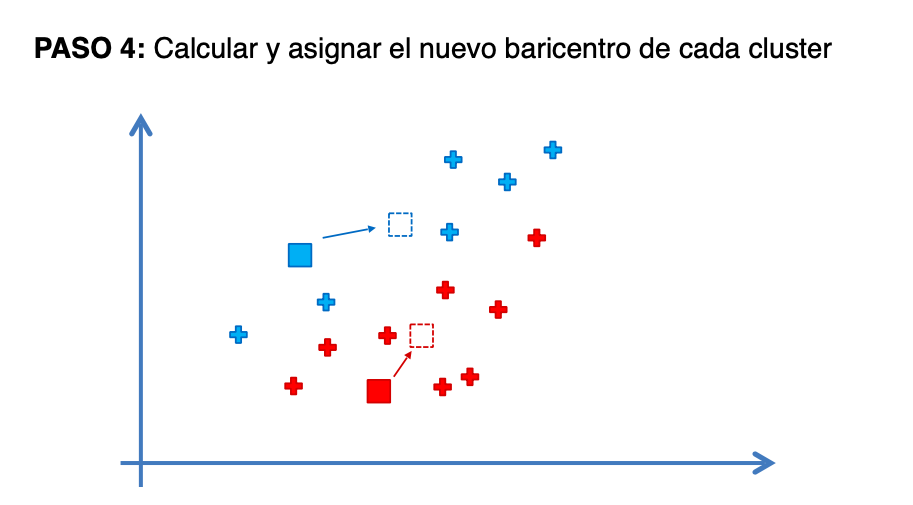

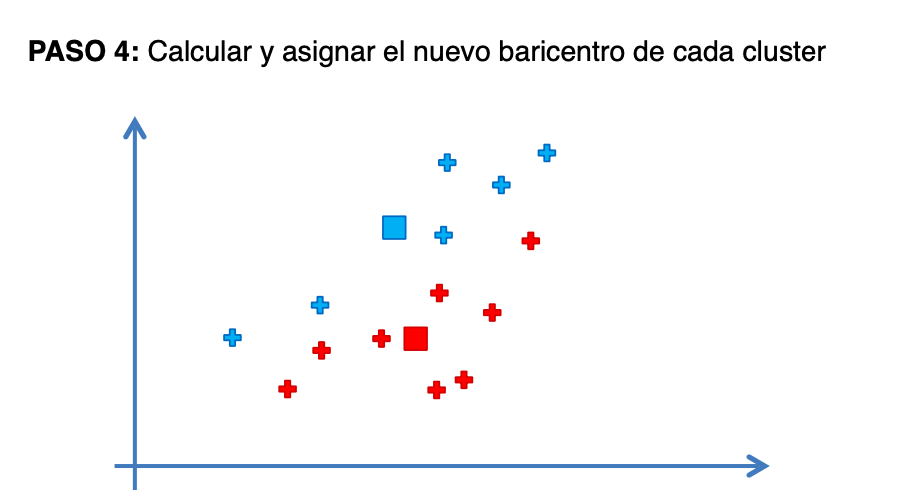

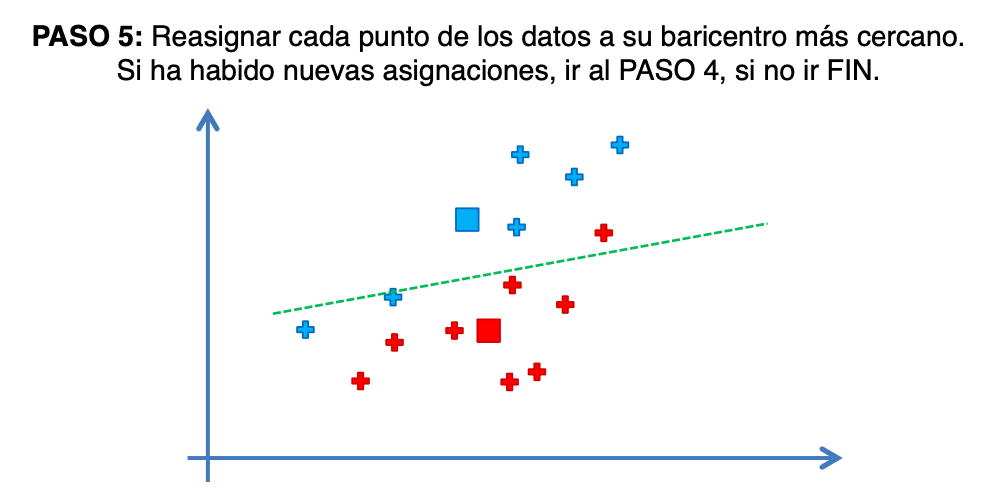

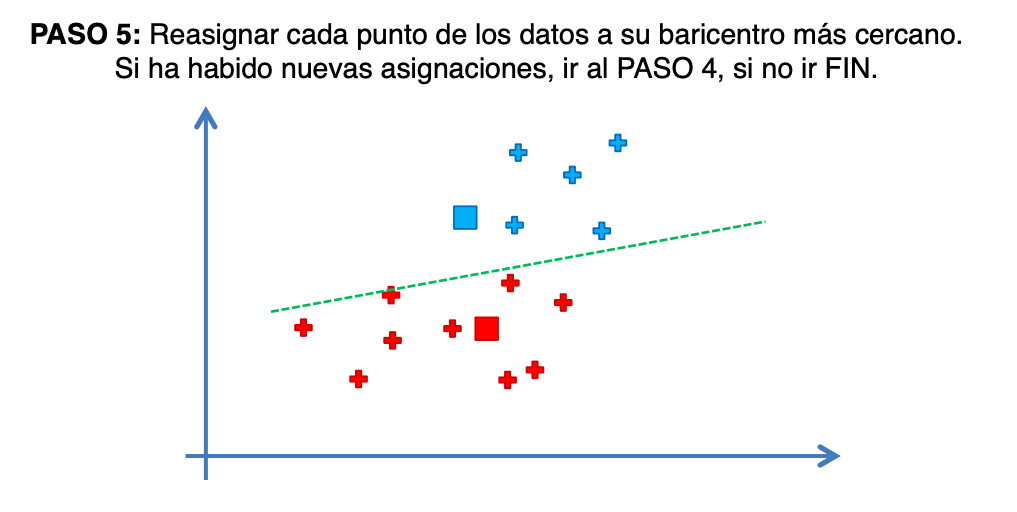

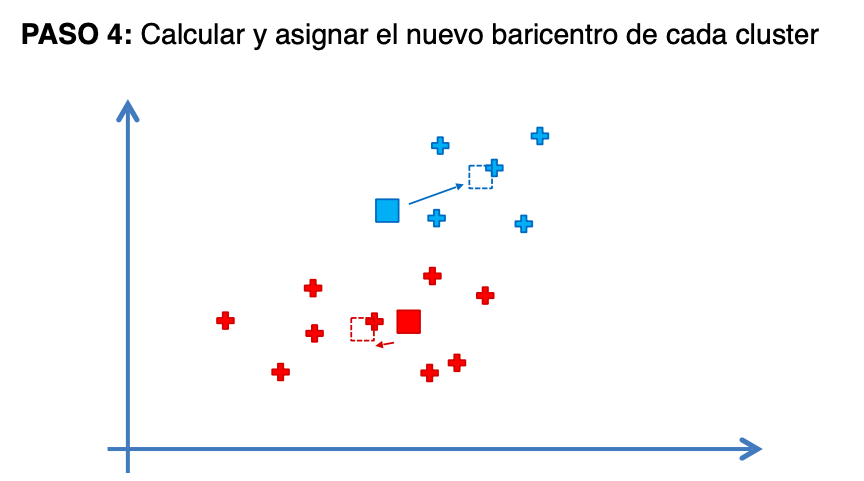

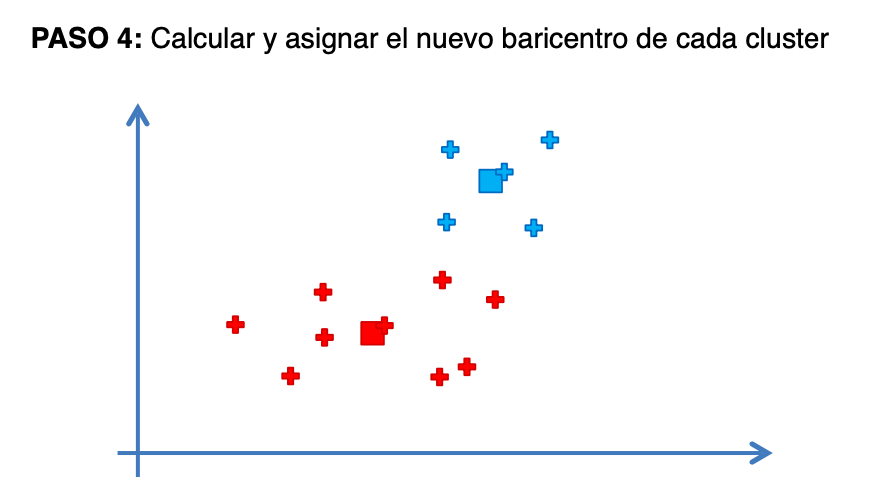

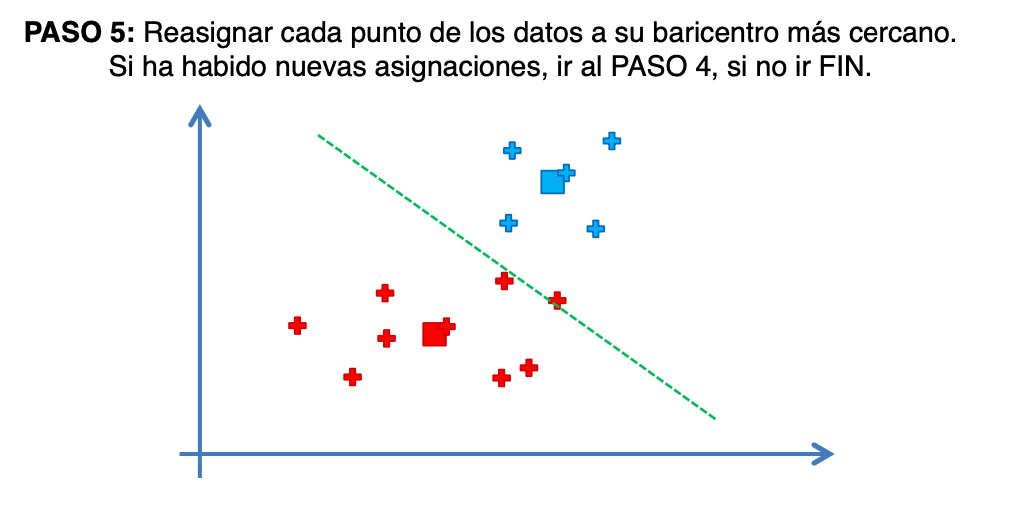

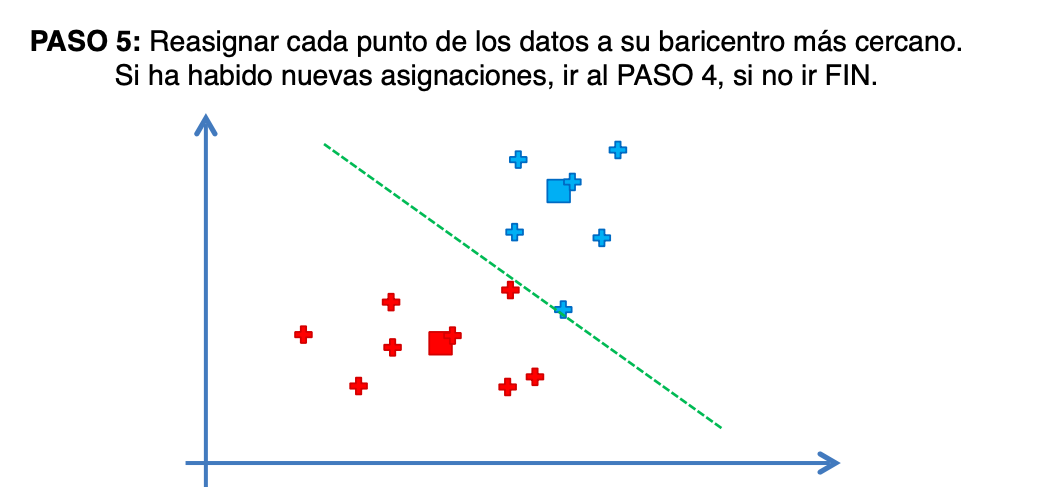

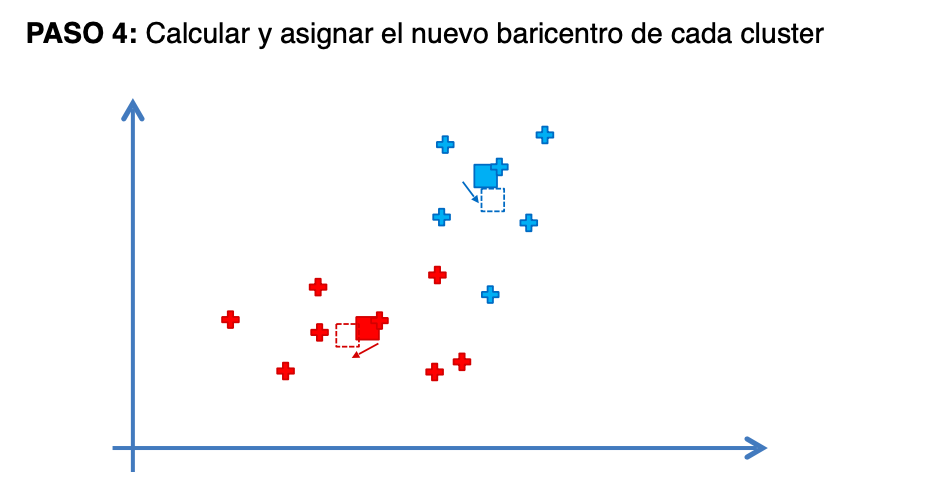

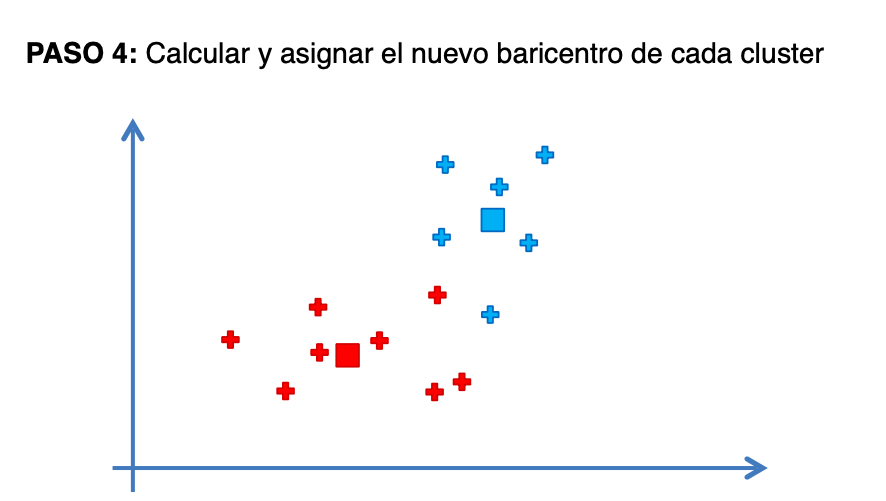

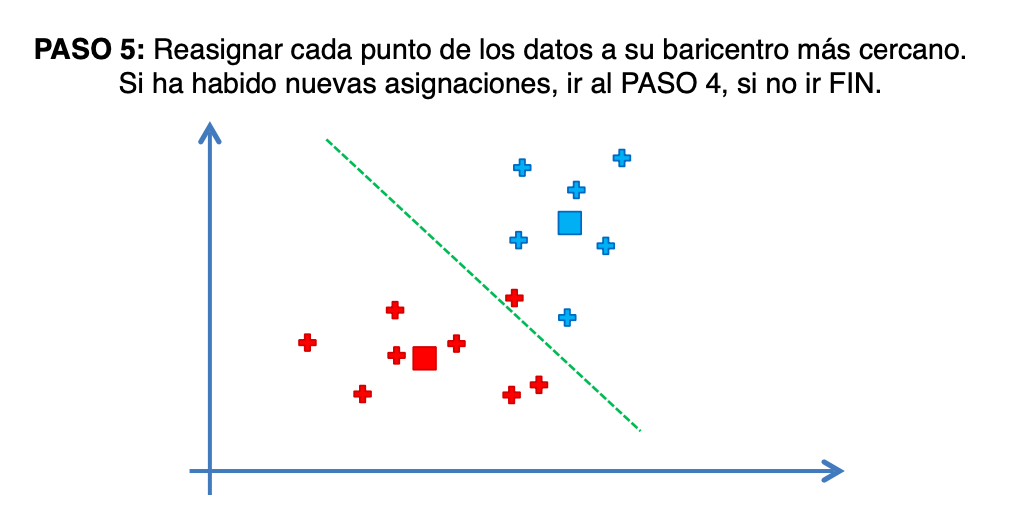

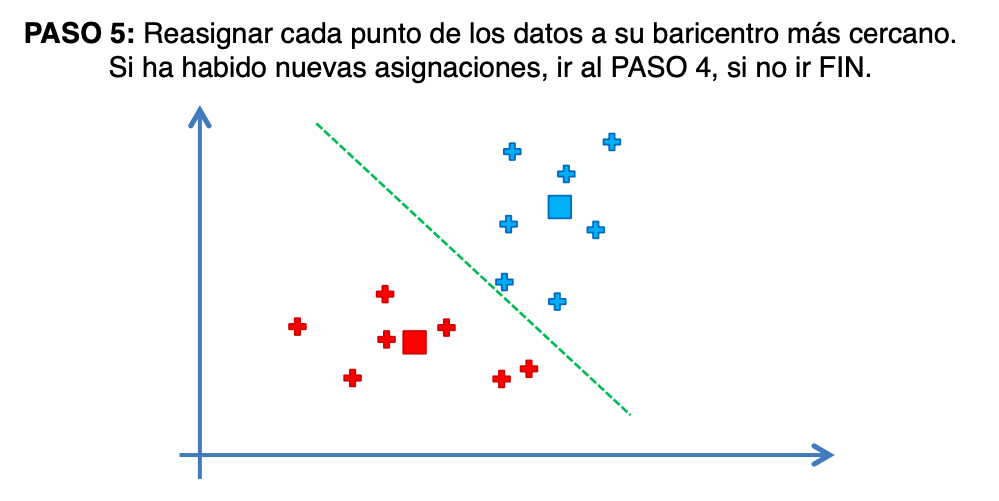

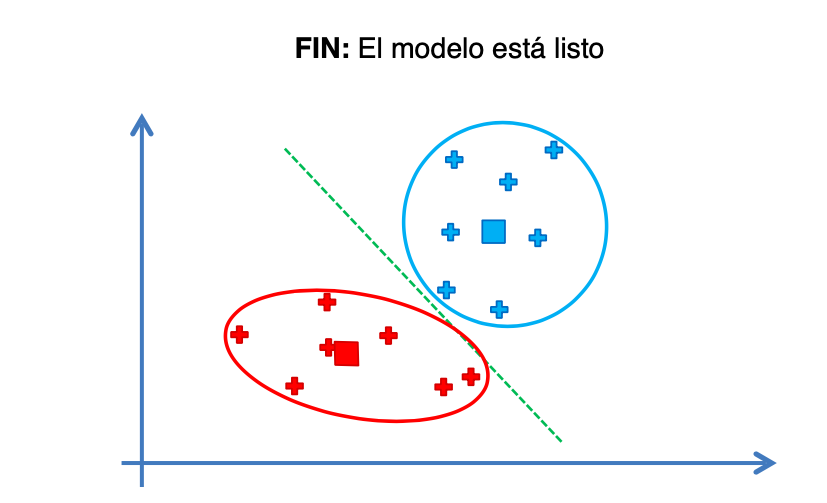

## ¿Cómo funciona el truco de la línea perpendicular cuando $k\geq 3$
Este truco se usa principalmente solo en espacios 2d o 3d. Por lo general, la distancia euclidiana se utiliza en todos los puntos de dimensiones altas para realizar la agrupación. En datos de muy alta dimensión, podríamos hacer un truco, que es una "esfera envolvente", es decir, comenzar en cada baricentro/centroide ($k$ esferas en total), comenzar a hacer crecer un espacio esférico (cìrculo en 2D, esfera en 3D, etc.), radialmente hacia afuera. Hasta que las esferas se crucen, todo lo que la esfera engulle pertenece al mismo cluster. Todos los demás puntos pueden asignarse a grupos calculando la distancia perpendicular entre los centroides.

## La trampa de la inicialización
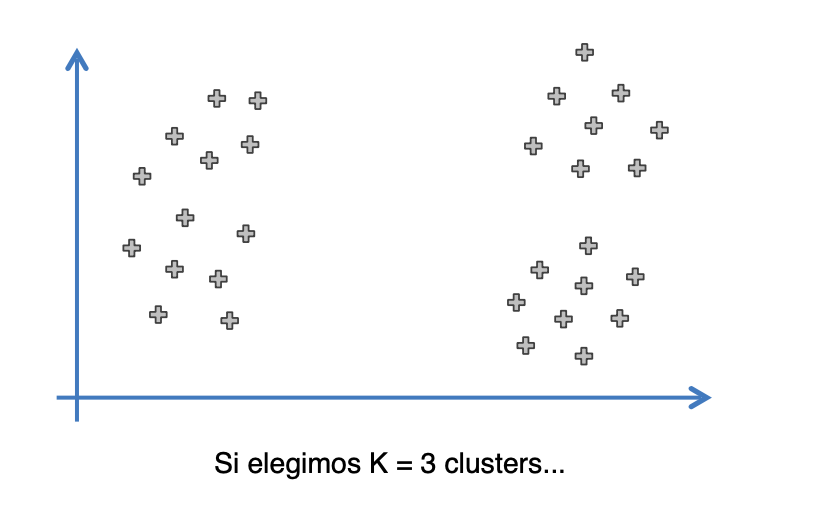

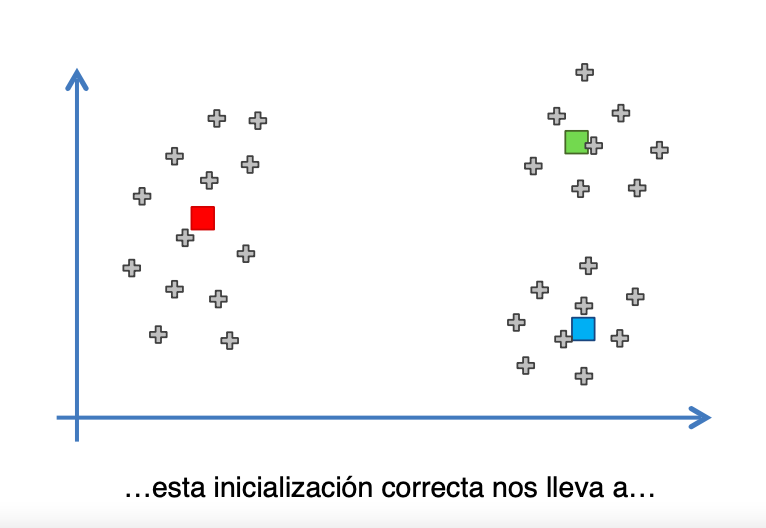

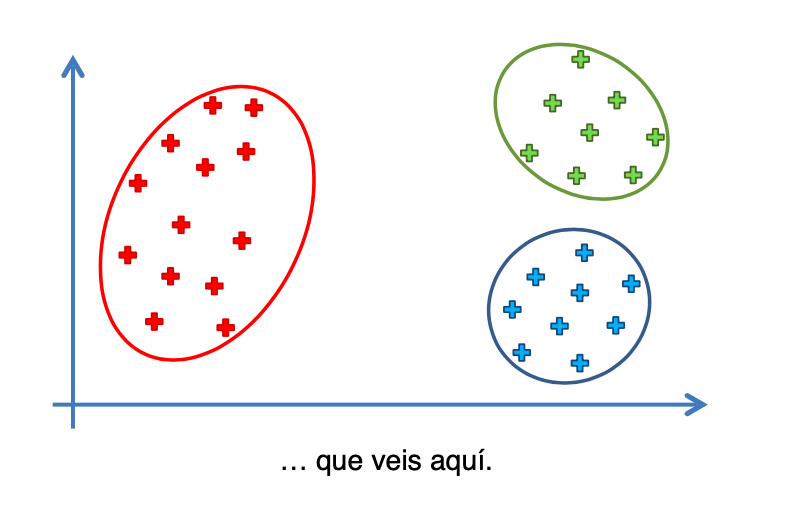

## ¿Qué pasaría si elegimos una mala inicialización aleatoria de los baricentros?
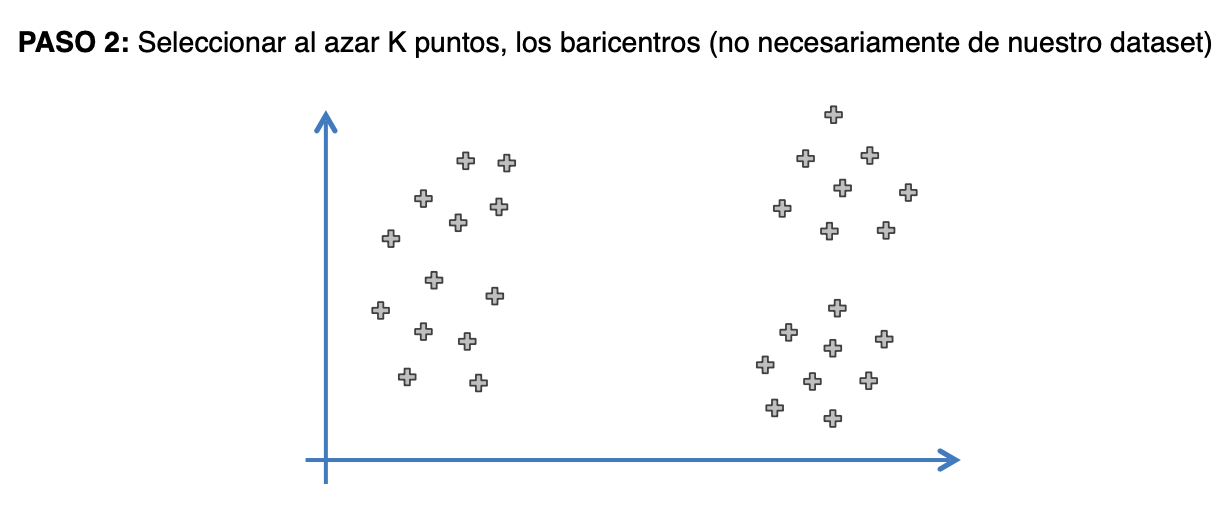

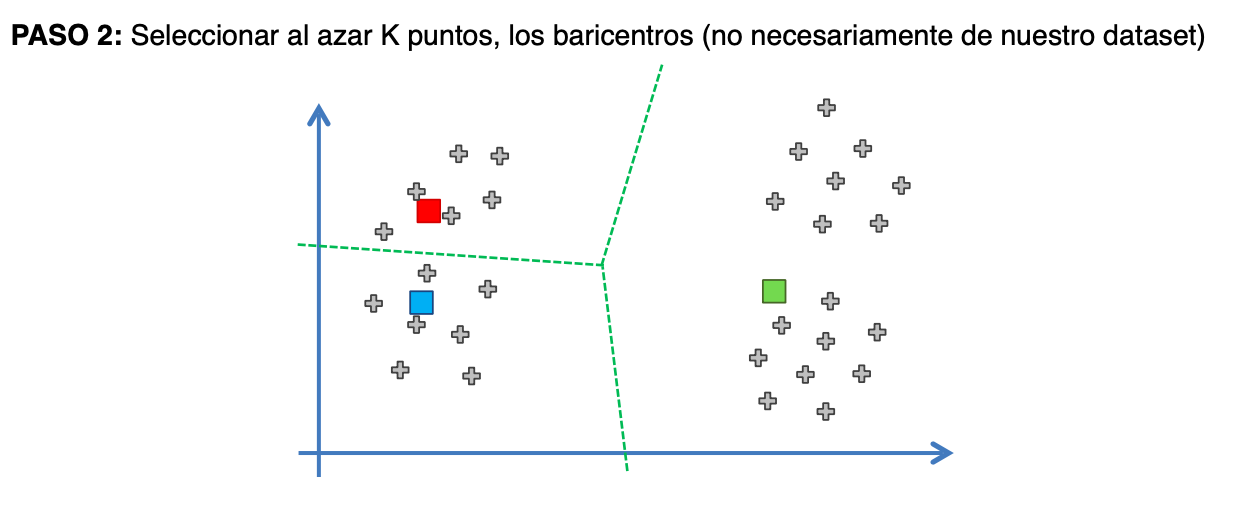

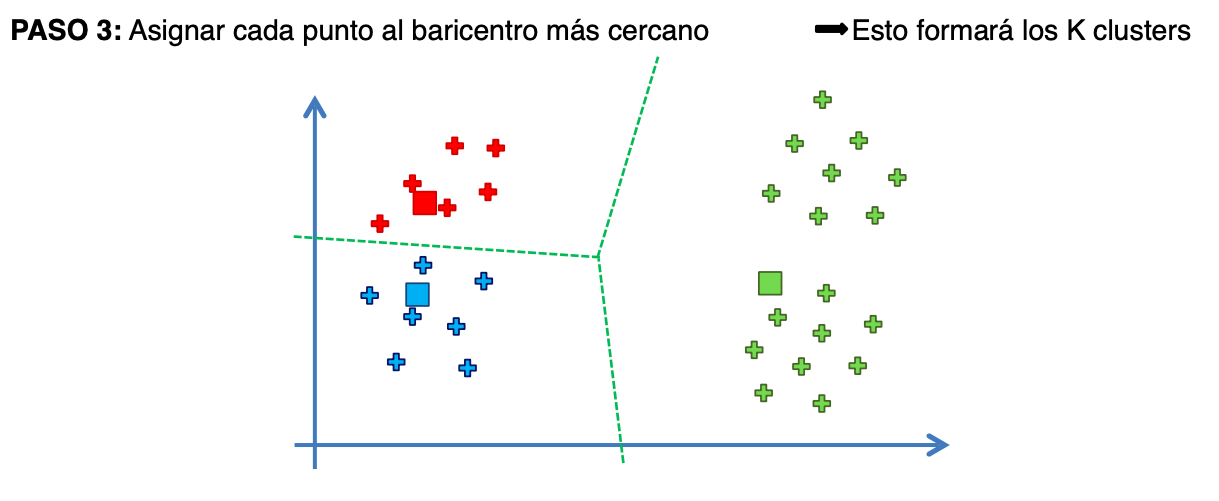

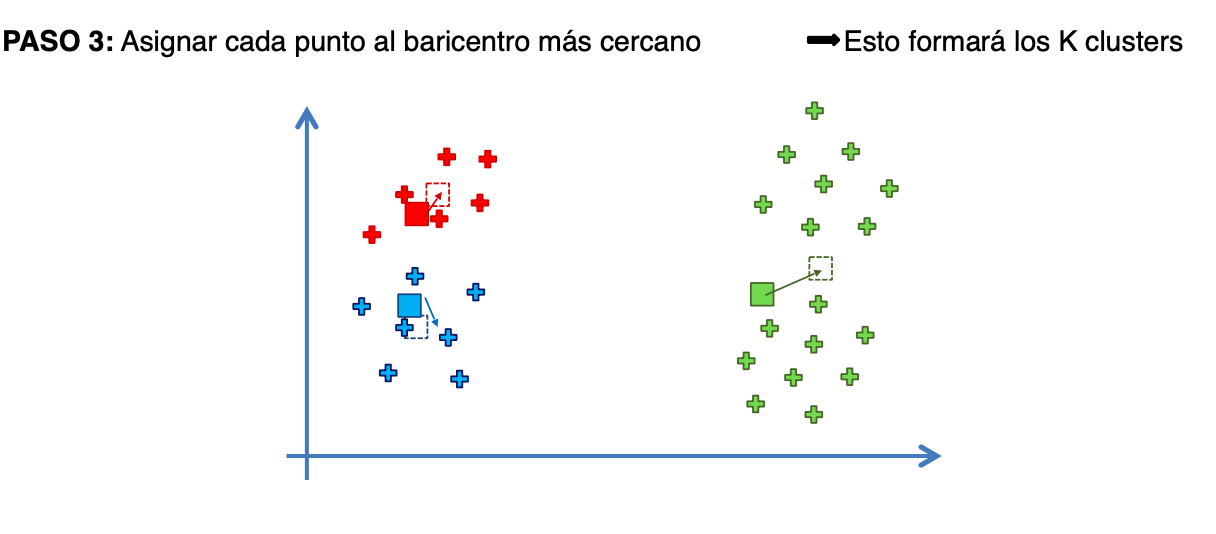

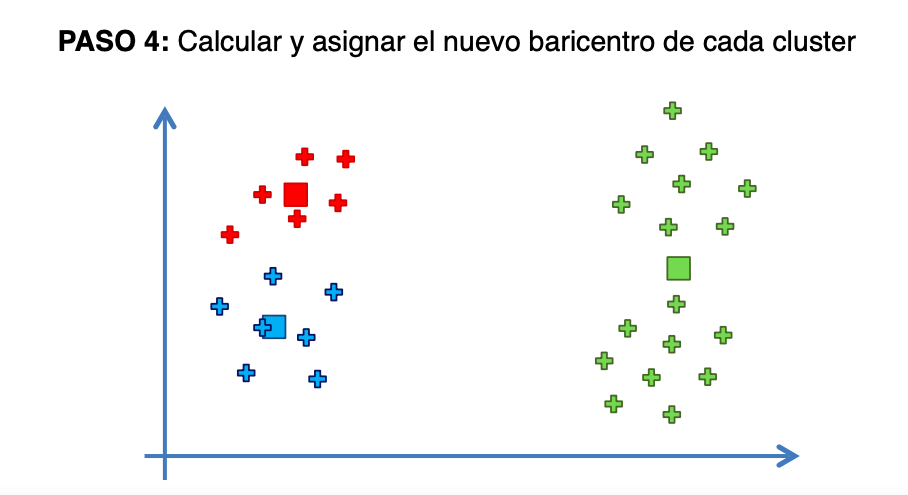

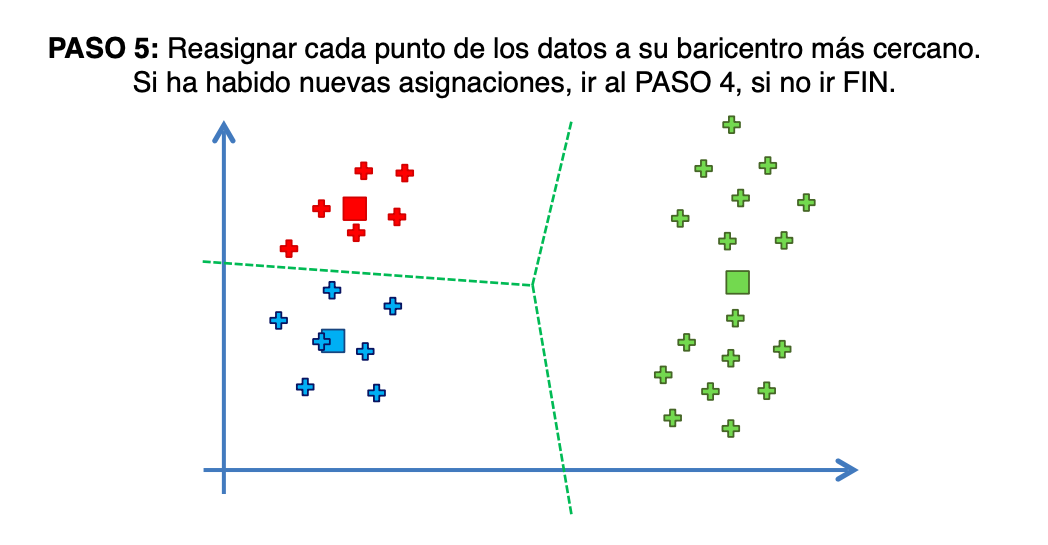

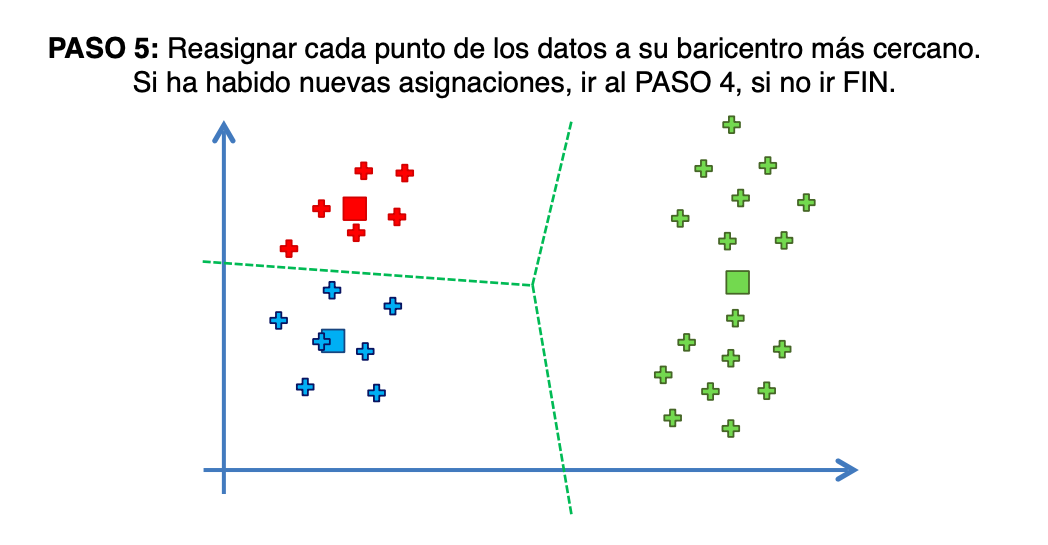

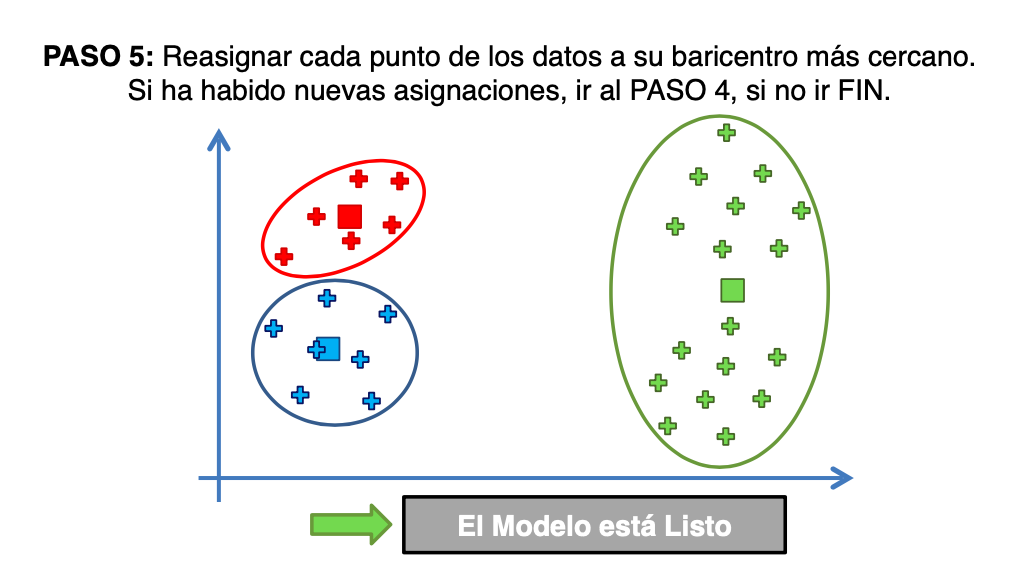

## Elegir el número correcto de clusters

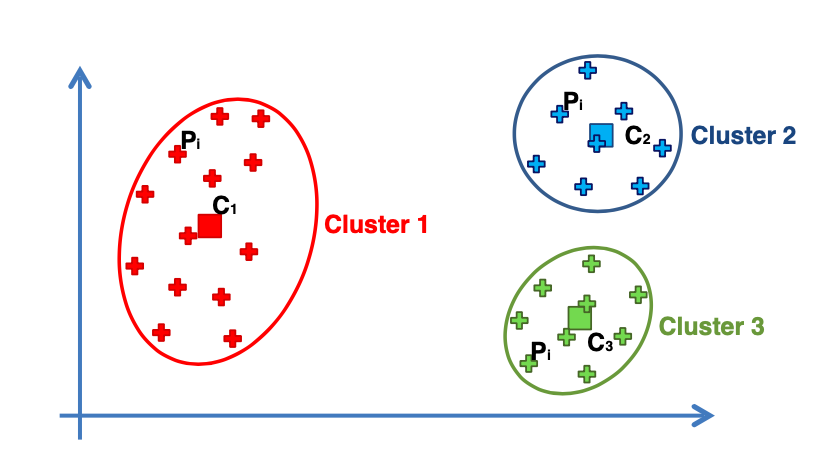

## La suma de cuadrados de los centros de clusters ()
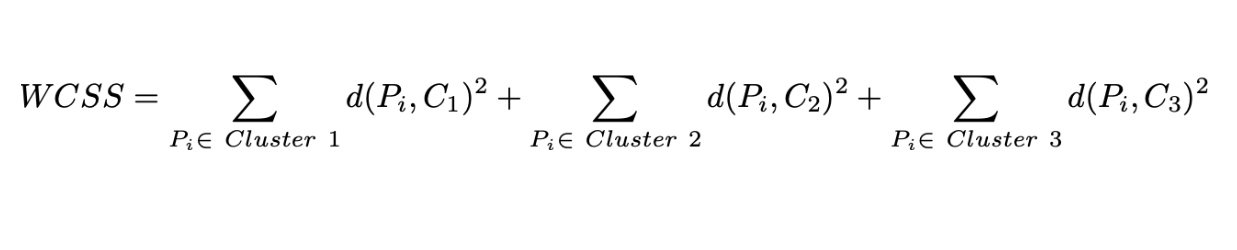

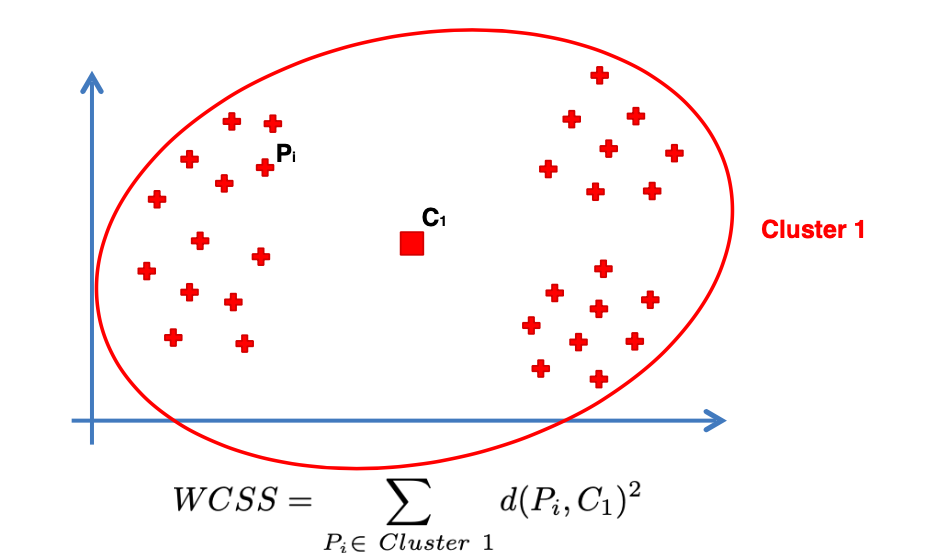

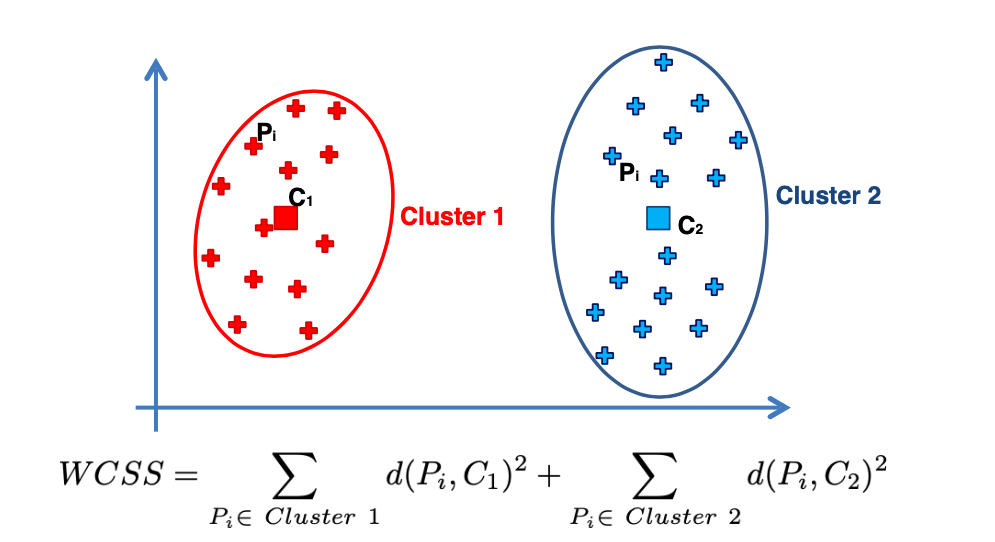

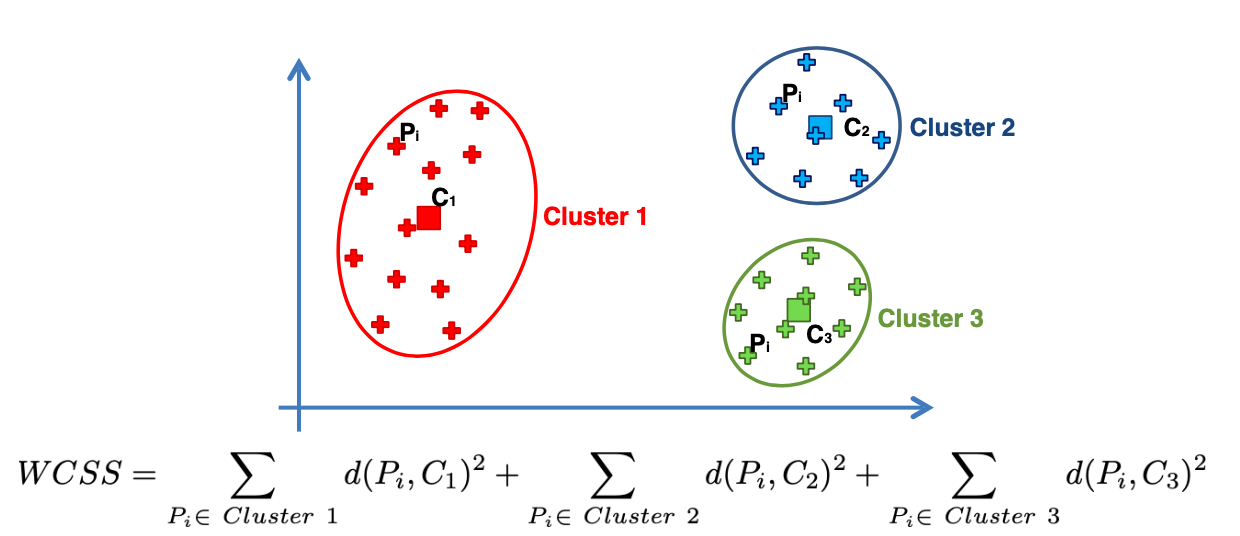

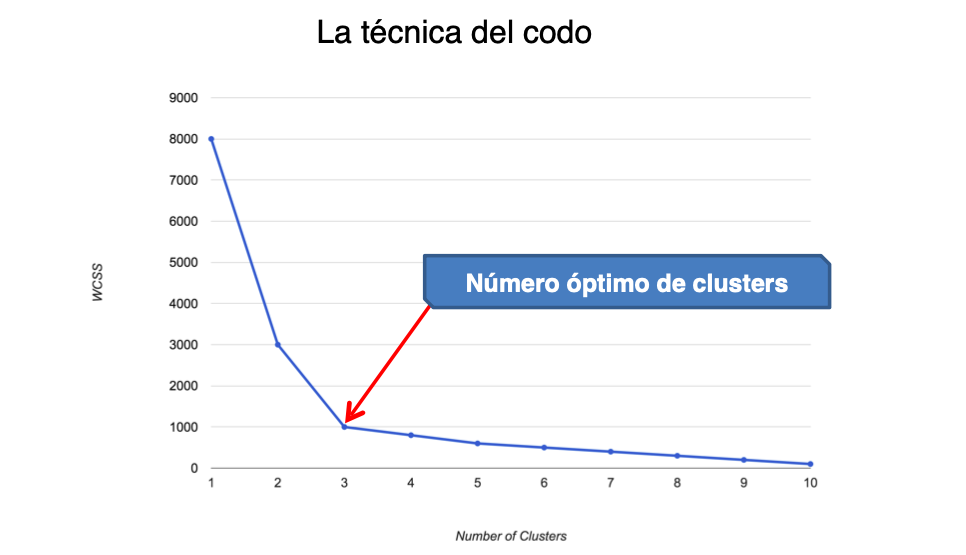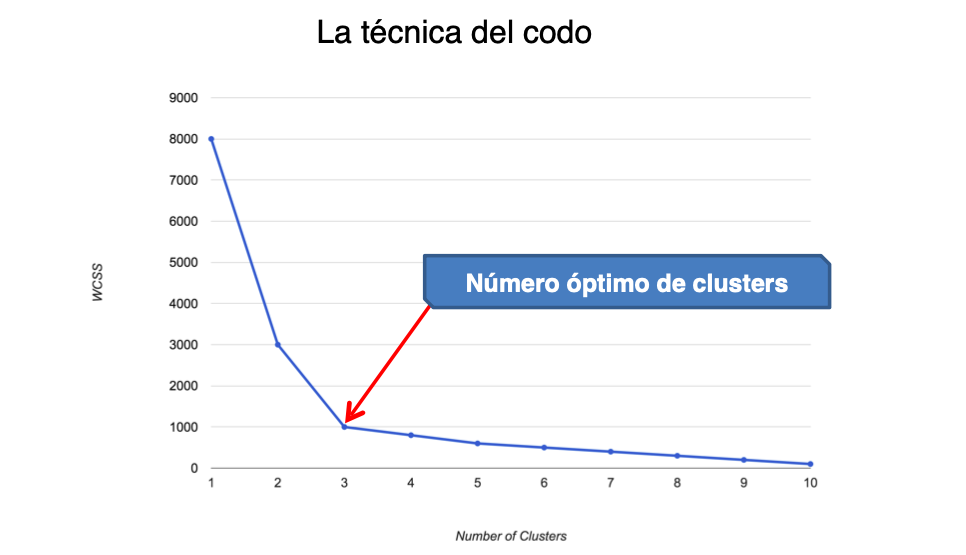

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
##geénero
#edad
#ingresos Anuales
#puntuaje de gasto
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Trabajo en clase
#Realizar un análisis descriptivo para visualizar que el ingreso anual si depende 
#de la edad y lo mismo con el género. 
#Realizar un análisis decriptivo para visualizar que el spending score depende 
#de la edad y el género. 
dataset.drop(['Genre'])

# Método del codo para averiguar el número de clusters

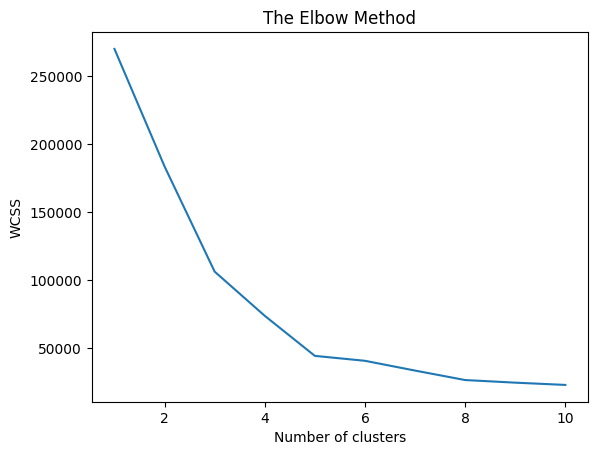

In [5]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11): ###los 10 primeros clusters
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) ###cuantos clusters #init-inicialización de los baricentros max_iter = 300, n_init = 10
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method') #regla del codo
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

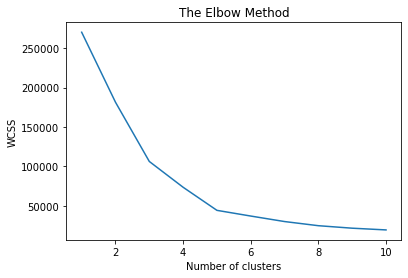

In [9]:
from sklearn.cluster import KMeans
wcss = [] 
for i in range(1, 11): ###los 10 primeros clusters
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) ###cuantos clusters #init-inicialización de los baricentros max_iter = 300, n_init = 10
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method') #regla del codo
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [10]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

## Visualising the clusters

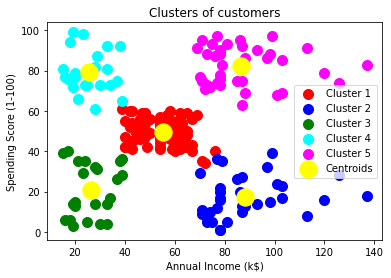

In [12]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1') #tamaño de bola
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [ ]:
# Tarea 1:  Dar la  interpretacíon de los 5 clusters 